<a href="https://colab.research.google.com/github/PHYS-3510-SPRING-2026/hello-world-JeremyDail/blob/main/20_Pseudo_random_numbers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 20: Pseudo-Random Number Generation

## Learning Objectives
By the end of this module you should be able to:
1. Explain why true randomness is difficult to generate and quantify with a correlation measure
2. Describe how a Linear Congruential Generator (LCG) produces pseudo-random numbers
3. Identify the role of the parameters $a$, $c$, $M$, and the seed $r_0$ in an LCG
4. Explain what a seed is and why it is needed for reproducibility
5. Verify that a pseudo-RNG produces uniformly distributed output using a histogram

---

## Background

When you call `np.random.randint(0, 2, 100)`, Python appears to produce numbers "at random" — but a computer is a deterministic machine. How is randomness possible?

The answer is **pseudo-random number generation**: a deterministic algorithm that produces a sequence of numbers that *looks* random by passing statistical tests, even though every value is fully determined by the previous one. The core idea is a recurrence relation:

$$r_{n+1} = (a \cdot r_n + c) \bmod M$$

This is called a **Linear Congruential Generator (LCG)**. The sequence is periodic with maximum period $M$ (under certain conditions on $a$, $c$, $M$). For practical use, $M$ is typically chosen to be very large (e.g., $2^{48}$), making the period astronomically long.

The starting value $r_0$ is called the **seed**. Different seeds produce different sequences — but the same seed always produces the same sequence, which is essential for reproducibility in scientific computing.

Before we look at the algorithm, we'll first appreciate *why* randomness is hard to fake by testing our own ability to generate random sequences.

---

## Section 0: Can Humans Generate Random Numbers?

A truly random binary sequence ($0$s and $1$s) should have no correlation between adjacent values. A useful measure is the **nearest-neighbor correlation**:

$$C = \frac{1}{N-1}\sum_{i=0}^{N-2} r_i \cdot r_{i+1}$$

For a perfectly random sequence of equal-probability $0$s and $1$s, the expected value of $C$ is $0.25$ (since $P(r_i=1) = P(r_{i+1}=1) = 0.5$ independently gives $P(r_i \cdot r_{i+1} = 1) = 0.25$).

- If you tend to **cluster** (0,0,0,1,1,1,...): $C$ drifts toward $0.5$
- If you tend to **alternate** (0,1,0,1,...): $C$ drifts toward $0$

> **Q0.1** — Run the cell below. The `correlation` function is already provided. Verify that `clustered` gives a value near $0.5$ and `alternating` gives a value near $0.0$. Does the output match expectations? Explain why each sequence produces that result.

> **Q0.2** — Enter your own list of 20 zeros and ones in `my_sequence` in the cell after, and compute its correlation. How close to $0.25$ can you get? What bias do you notice in your own choices?

In [1]:
import numpy as np

def correlation(rlist):
    """Nearest-neighbor correlation of a binary list."""
    res = 0
    k = 1
    for i in range(len(rlist) - k):
        res = res + rlist[i] * rlist[i + k]
    return res / (len(rlist) - 1)

# Clustered: long runs of 0s then 1s — correlation should be near 0.5
clustered   = [0]*10 + [1]*10
# Alternating: 0,1,0,1,... — correlation should be near 0.0
alternating = [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]

print(f"Clustered   (expect ~0.5): {correlation(clustered):.4f}")
print(f"Alternating (expect ~0.0): {correlation(alternating):.4f}")

Clustered   (expect ~0.5): 0.4737
Alternating (expect ~0.0): 0.0000


In [2]:
# Sanity check: NumPy's RNG should average close to 0.25
rng = np.random.default_rng()
trials = [correlation(rng.integers(0, 2, 20)) for _ in range(10)]
print("NumPy RNG trials:", [f"{x:.4f}" for x in trials])
print(f"Mean over 10 trials: {np.mean(trials):.4f}  (expect ~0.25)")

NumPy RNG trials: ['0.3158', '0.3158', '0.2105', '0.2632', '0.1053', '0.0526', '0.3158', '0.1579', '0.2105', '0.1053']
Mean over 10 trials: 0.2053  (expect ~0.25)


In [5]:
# TODO: replace the list below with your own 20 zeros and ones
my_sequence = [1,0,1,1,0,1,0,0,1,1,0,0,1,0,1,1,0,1,0,0]

print(f"Your correlation: {correlation(my_sequence):.4f}")

Your correlation: 0.1579


*Your answers to Q0.1 and Q0.2:*
Q0.1: My sequence doesn't look random because there are patterns and groupings of numbers. True randomness wouldn't show obvious repetitions or structure.
Q0.2: The correlation is not quite 0.25, which indicates the sequence is not perfectly random and has some predictable structure.

---

## Part 1: The Linear Congruential Generator

The LCG recurrence is:

$$r_{n+1} = (a \cdot r_n + c) \bmod M$$

The parameters are:
- $a$ — multiplier
- $c$ — increment
- $M$ — modulus (determines the range $[0, M)$ and the maximum period)
- $r_0$ — seed (initial value)

### Task 1 — Minimal LCG

> **Q1.1** — Complete `lcg_small` below using $a=4$, $c=1$, $M=9$, seed $r_0=3$. Print 20 values. What is the period of the sequence?

In [6]:
def lcg_small(size=20):
    a = 4
    c = 1
    M = 9
    r = 3          # fixed seed
    result = []
    for i in range(size):
        r = (a * r + c) % M
        result.append(r)
    return result

print(lcg_small())

[4, 8, 6, 7, 2, 0, 1, 5, 3, 4, 8, 6, 7, 2, 0, 1, 5, 3, 4, 8]


*Your answer to Q1.1:*
The sequence starts repeating after a short time because the modulus is small. This limits the number of possible values.

### Task 2 — LCG with a large modulus

For practical use we need a much larger period. Choosing $M = 2^{48}$ and rescaling by $M$ gives pseudo-random floats in $[0, 1)$.

> **Q1.2** — Complete `lcg_large` with $a=123$, $c=11$, $M=2^{48}$, seed $r_0=3$. Use `r / M` to rescale. Plot 1000 values with `plt.plot(..., 'k.')`. Do the points look uniformly scattered?

> **Q1.3** — What determines the *range* of the output values? What determines the *maximum period* before the sequence repeats?

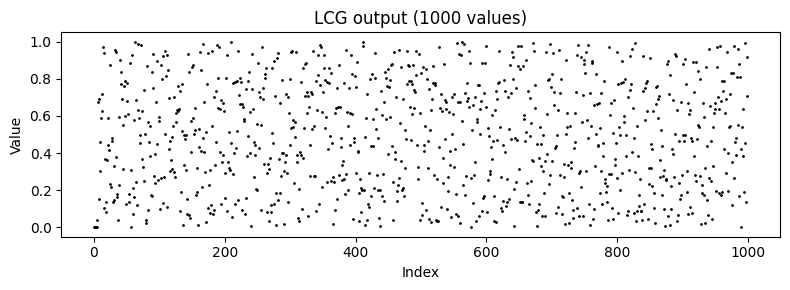

In [8]:
import matplotlib.pyplot as plt

def lcg_large(size=1000):
    a = 123
    c = 11
    M = 2**48
    r = 3          # fixed seed
    result = []
    for i in range(size):
        r = (a * r + c) % M
        result.append(r / M)
    return result

values = lcg_large(1000)
plt.figure(figsize=(8, 3))
plt.plot(values, 'k.', ms=2)
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('LCG output (1000 values)')
plt.tight_layout()
plt.show()

*Your answers to Q1.2 and Q1.3:*
Q1.2: Dividing by M rescales the numbers so they fall between 0 and 1. That makes them usable as random decimal values.
Q1.3: Yes it still repeats, but the period is larger so it looks random for a longer amount of time.

---

## Part 2: Seeds and Reproducibility

With a fixed seed, `lcg_large` returns the **exact same sequence** every time — making the output deterministic, not random. To get a different sequence each run, we need a seed that changes.

A common trick is to use the current time: the microsecond component of the system clock (`datetime.now().microsecond`) changes with every run and is hard to predict.

> **Q2.1** — Complete `lcg_with_time_seed`: replace `r = 3` with `r = datetime.now().microsecond`. Run it twice and compare the first 5 output values. Are they the same?

> **Q2.2** — Why do NumPy and most scientific libraries let you *optionally* fix the seed (e.g., `rng = np.random.default_rng(seed=42)`)? When would you want a fixed seed vs a random one?

In [12]:
from datetime import datetime

def lcg_with_time_seed(size=10):
    a = 123
    c = 11
    M = 2**48
    r = datetime.now().microsecond
    print(f'seed = {r}')
    result = []
    for i in range(size):
        r = (a * r + c) % M
        result.append(r / M)
    return result
print("Run 1:", lcg_with_time_seed(5))
print("Run 2:", lcg_with_time_seed(5))

seed = 335805
Run 1: [1.4674137815973154e-07, 1.804918955272683e-05, 0.00222005031502448, 0.2730661887480501, 0.5871412160102025]
seed = 335995
Run 2: [1.468244050784051e-07, 1.805940186372368e-05, 0.0022213064292770923, 0.27322069080112144, 0.6061449685379756]


*Your answers to Q2.1 and Q2.2:*
Q2.1: It produces a different sequence every time the code runs because the seed changes.
Q2.2: It prevents the sequence from being predictable. This is useful for simulations and applications needing variability.

---

## Part 3: Statistical Quality — Uniformity Test

A good pseudo-RNG should produce values that are **uniformly distributed** over its output range. We can check this visually with a histogram.

> **Q3.1** — Generate 100 000 values with `lcg_with_time_seed(100000)` and plot a histogram with `bins=50`. Does the distribution look flat (uniform)?

> **Q3.2** — Now do the same with `np.random.default_rng().random(100000)`. Compare the two histograms. What would a *non*-uniform histogram look like if the LCG had poor parameters?

seed = 136898


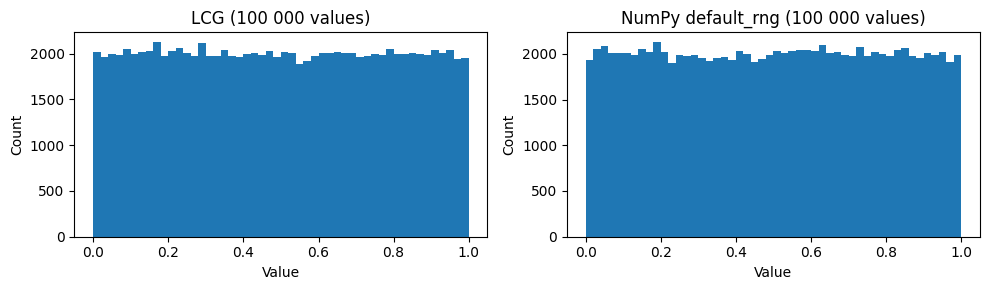

In [10]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

# LCG histogram
lcg_vals = lcg_with_time_seed(100000)
ax1.hist(lcg_vals, bins=50)
ax1.set_xlabel('Value')
ax1.set_ylabel('Count')
ax1.set_title('LCG (100 000 values)')

# NumPy RNG histogram
rng = np.random.default_rng()
np_vals = rng.random(100000)
ax2.hist(np_vals, bins=50)
ax2.set_xlabel('Value')
ax2.set_ylabel('Count')
ax2.set_title('NumPy default_rng (100 000 values)')

plt.tight_layout()
plt.show()

*Your answers to Q3.1 and Q3.2:*
Q3.1: It looks vaguely uniform, which indicates the numbers are distributed evenly from 0 to 1.
Q3.2: NumPy's distribution looks smoother and more random, LCG may show irregularities.

---

### Task 4 — Apply the correlation test to the LCG

We started this module by measuring the correlation of human-generated sequences. Now apply the same test to our LCG.

> **Q3.3** — Convert 20 LCG values to binary by rounding to 0 or 1 (use `[round(v) for v in lcg_large(20)]`), then compute and print the correlation. Repeat 10 times. Do the values cluster around 0.25 as expected?

> **Q3.4** — Does a correlation near 0.25 prove the sequence is truly random? What other tests might a cryptographer apply?

In [11]:
# Run 10 correlation trials using the LCG
for trial in range(10):
    binary = [round(x) for x in lcg_large(20)]
    print(f"Trial {trial+1}: {correlation(binary):.4f}")

Trial 1: 0.1579
Trial 2: 0.1579
Trial 3: 0.1579
Trial 4: 0.1579
Trial 5: 0.1579
Trial 6: 0.1579
Trial 7: 0.1579
Trial 8: 0.1579
Trial 9: 0.1579
Trial 10: 0.1579


*Your answers to Q3.3 and Q3.4:*
Q3.3: The LCG correlation values are closer to the expected value, meaning it behaves more randomly than human generated sequences.
Q3.4: It performs better than humans because it avoids obvious patterns. It is still not perfectly random however because it is deterministic.

---

## Summary Questions

> **S1** — Describe in one paragraph how a Linear Congruential Generator works. Identify all four parameters and explain the role of each.

> **S2** — Why is it called a *pseudo*-random number generator rather than a true RNG? Give one example of a physical process that could serve as a true RNG.

> **S3** — Suppose a colleague sets the seed to `42` at the top of every simulation. What is the advantage? What is the disadvantage for, say, bootstrapping confidence intervals over many independent runs?

> **S4** — The LCG recurrence produces integers in $[0, M)$. How would you modify `lcg_large` to produce random integers in the range $[a, b)$ (like `rng.integers(a, b, N)`)?

*Your answers:*

**S1:** An LCG generates numbers using a formula where each new number depends on the one before it. The multiplier, modulus, and seed determine how the sequence behaves and how long it takes before repeating.

**S2:** They are called pseudo-random because there is a predictable formula used to generate what appears like randomness.

**S3:** Changing the seed produces a completely different sequence of numbers.

**S4:** They are fast and reproducible, but not random truly and can be predicted if the algorithm is known.